<a href="https://colab.research.google.com/github/BOUIDA-CHAIMA/Machine-Learning-samples/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
rng = np.random.default_rng(42)            # 42 = graine : mêmes résultats à chaque exécution
heures = rng.uniform(0, 10, 100)           # 100 élèves, entre 0 et 10 h d'étude
note = 2 * heures + rng.normal(0, 1.5, 100)   # note ≈ 2 × heures + un peu de hasard

df = pd.DataFrame({"heures": heures, "note": note})
df.head()

,heures,note
0,7.739560,16.078782
1,4.388784,7.419350
2,8.585979,16.604715
3,6.973680,15.896203
4,0.941773,1.349151


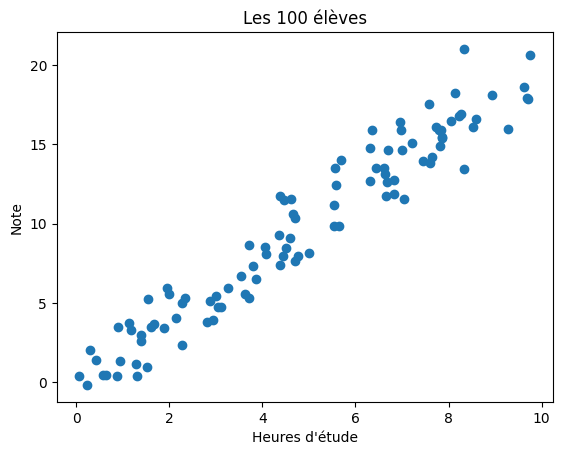

In [6]:
plt.scatter(df["heures"], df["note"])
plt.xlabel("Heures d'étude")
plt.ylabel("Note")
plt.title("Les 100 élèves")
plt.show()

In [7]:
X = df[["heures"]]    # l'entrée (doubles crochets : un tableau, pas une liste)
y = df["note"]        # ce qu'on veut prédire

In [8]:
# 1er découpage : 20 % pour le test, on le met de côté
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2e découpage : sur les 80 % restants, 25 % pour la validation (= 20 % du total)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print("train :", len(X_train), "| validation :", len(X_val), "| test :", len(X_test))

train : 60 | validation : 20 | test : 20


In [9]:
modele = LinearRegression()
modele.fit(X_train, y_train)      # ← c'est ici que le modèle apprend

print(f"w (pente) = {modele.coef_[0]:.2f}")
print(f"b (biais) = {modele.intercept_:.2f}")

w (pente) = 2.03
b (biais) = -0.11


In [10]:
for nom, (A, b) in {"train": (X_train, y_train),
                    "validation": (X_val, y_val),
                    "test": (X_test, y_test)}.items():
    prediction = modele.predict(A)
    print(f"{nom:10} MSE = {mean_squared_error(b, prediction):.2f}   R² = {r2_score(b, prediction):.2f}")

train      MSE = 2.27   R² = 0.92
validation MSE = 2.15   R² = 0.94
test       MSE = 1.87   R² = 0.94


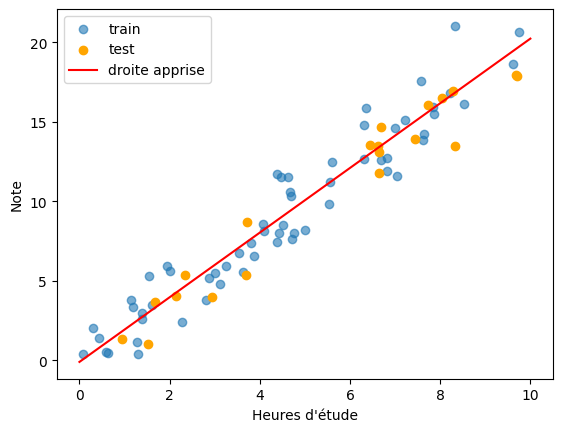

In [11]:
plt.scatter(X_train, y_train, label="train", alpha=0.6)
plt.scatter(X_test, y_test, label="test", color="orange")
xs = pd.DataFrame({"heures": np.linspace(0, 10, 50)})
plt.plot(xs, modele.predict(xs), color="red", label="droite apprise")
plt.xlabel("Heures d'étude"); plt.ylabel("Note"); plt.legend()
plt.show()

In [12]:
nouveau = pd.DataFrame({"heures": [5]})
print("Note prédite pour 5 h :", modele.predict(nouveau)[0])

Note prédite pour 5 h : 10.057830758567714
